In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Data
file_path = 'cleaned-before_log.csv'
df = pd.read_csv(file_path)

print(f"Original Dataset Size: {df.shape}")

Original Dataset Size: (11441, 15)


In [2]:
# Define Smart Outlier Removal Function

def remove_outliers_by_brand(df, make_col='Make', price_col='Price'):
    """
    Removes price outliers for each specific car brand using the IQR method.
    Using a threshold of 3.0 ensures we only remove extreme errors (like typos),
    preserving genuine expensive trims.
    """
    df_cleaned = df.copy()
    keep_indices = []
    
    # Iterate through every unique car brand
    for make, group in df_cleaned.groupby(make_col):
        # Calculate price statistics for this specific brand
        Q1 = group[price_col].quantile(0.25)
        Q3 = group[price_col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define acceptable range (3.0 * IQR handles extreme outliers well)
        lower_bound = Q1 - 3.0 * IQR
        upper_bound = Q3 + 3.0 * IQR
        
        # Keep rows that are within the acceptable price range
        mask = (group[price_col] >= lower_bound) & (group[price_col] <= upper_bound)
        keep_indices.extend(group[mask].index.tolist())
        
    return df_cleaned.loc[keep_indices]

# Apply Cleaning & Verify
df_clean = remove_outliers_by_brand(df)

print(f"Cleaned Dataset Size: {df_clean.shape}")
print(f"Removed {len(df) - len(df_clean)} rows containing unrealistic prices.")

Cleaned Dataset Size: (11344, 15)
Removed 97 rows containing unrealistic prices.


In [3]:
# Check the specific Suzuki issue you mentioned
print("\n--- Max Price Check ---")
print(f"Max Suzuki Price BEFORE: {df[df['Make']=='Suzuki']['Price'].max():,.0f} LKR")
print(f"Max Suzuki Price AFTER:  {df_clean[df_clean['Make']=='Suzuki']['Price'].max():,.0f} LKR")


--- Max Price Check ---
Max Suzuki Price BEFORE: 105,000,000 LKR
Max Suzuki Price AFTER:  13,200,000 LKR


C:\Users\Ramiru\AppData\Local\Temp\ipykernel_15844\1291111084.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
C:\Users\Ramiru\AppData\Local\Temp\ipykernel_15844\1291111084.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)


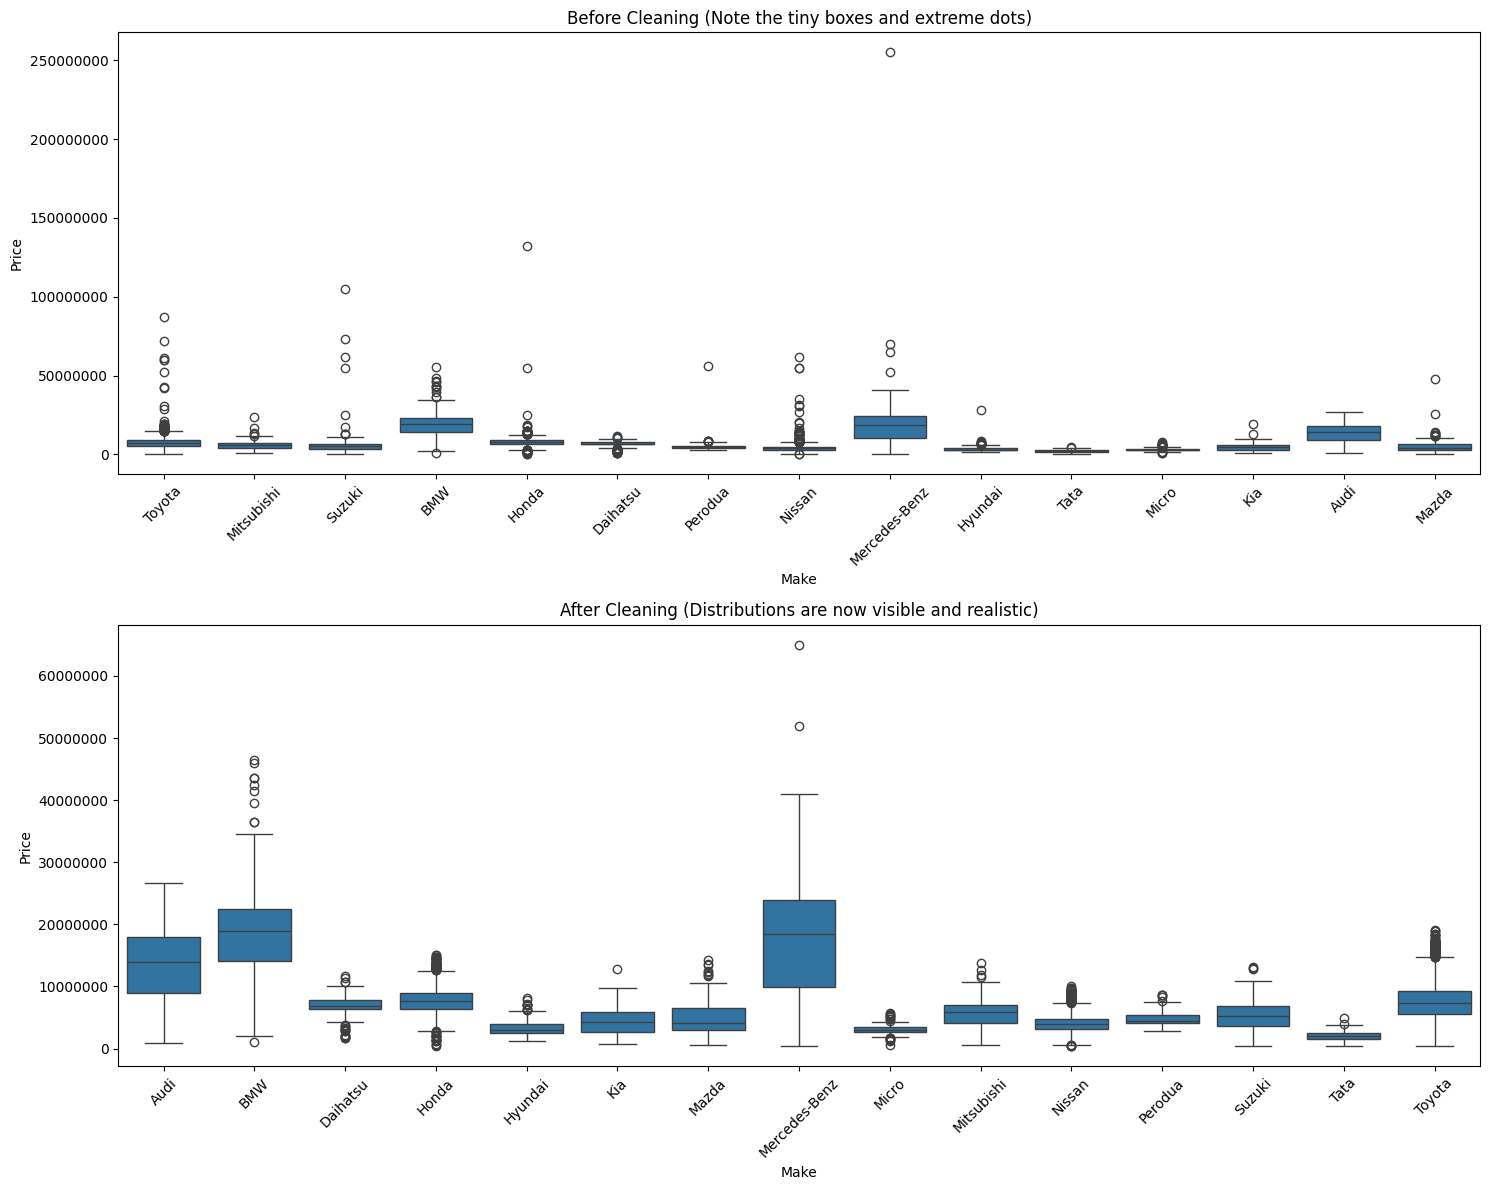


Success! Cleaned data saved to: cleaned_no_outliers.csv


In [4]:
# Visualization (Before vs After)
# Select top 15 brands for a cleaner plot
top_makes = df['Make'].value_counts().nlargest(15).index

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot Before
sns.boxplot(data=df[df['Make'].isin(top_makes)], x='Make', y='Price', ax=axes[0])
axes[0].set_title('Before Cleaning (Note the tiny boxes and extreme dots)')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Plot After
sns.boxplot(data=df_clean[df_clean['Make'].isin(top_makes)], x='Make', y='Price', ax=axes[1])
axes[1].set_title('After Cleaning (Distributions are now visible and realistic)')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


# Save the Cleaned File

output_filename = 'cleaned_no_outliers.csv'
df_clean.to_csv(output_filename, index=False)
print(f"\nSuccess! Cleaned data saved to: {output_filename}")